# 2.11b — Operateurs proximaux : ISTA et FISTA from scratch

**Sous-grain Bloc A.3 #16061** : methodes de premier ordre pour la minimisation
`min_x f(x) + g(x)` ou `f` est differentiable a gradient Lipschitz et `g` est
un terme non lisse (typiquement une regularisation L1). ISTA (Iterative
Shrinkage-Thresholding Algorithm) effectue un pas de gradient sur `f` suivi
d'un pas proximal sur `g`. FISTA (Fast ISTA) ajoute l'inertie de Nesterov et
obtient la convergence `O(1/k^2)` au lieu de `O(1/k)`.

L'application canonique est la **sparse recovery** : retrouver un signal
`x* ∈ R^p` parcimonieux a partir de mesures compressees `b = A x*` avec
`A ∈ R^{n x p}, n < p`. La relaxation L1 est convexifie ce probleme
inverse mal pose.

**Stack** : `numpy`, `scipy` pour la generation de signaux, `scikit-learn`
pour `Lasso` (baseline coordinate descent), `cvxpy` pour la verite terrain
(SOCP/CLARABEL). Pas d'utilisation de `sklearn.linear_model` dans la boucle
interne d'optimisation (SOTA : on implemente nous-memes ISTA et FISTA).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
np.random.seed(42)
print('Bibliotheques importees.')

Bibliotheques importees.


## 1. Operateur proximal de la norme L1 (soft-thresholding)

L'operateur proximal de `g(x) = lambda * ||x||_1` est le **soft-thresholding**
(vectorise, applique coordonnee par coordonnee) :

```
prox_{lambda L1}(x)_i = S_{lambda}(x_i) = sign(x_i) * max(|x_i| - lambda, 0)
```

C'est la fonction de shrinkage bien connue (Donoho, Johnstone). Ses proprietes :
- Continu, contractant de facteur 1, ferme.
- Fixe la parcimonie : si `|x_i| < lambda`, la coordonnee est annulee.
- Pour `lambda = 0`, c'est l'identite.

La derivation vient du sous-differentiel `0 ∈ x - v + lambda * ∂||v||_1` :
pour `v_i ≠ 0`, `∂|v_i|/∂v_i = sign(v_i)`, donc `v_i = S_lambda(x_i) = sign(x_i)(|x_i|-lambda)_+`.


In [2]:
def prox_l1(x, lam):
    """Operateur proximal de la norme L1 : soft-thresholding elementwise.

    Parameters
    ----------
    x : array-like, shape (n,)
        Vecteur d'entree.
    lam : float
        Coefficient de regularisation L1 (>= 0).

    Returns
    -------
    v : ndarray, shape (n,)
        prox_{lam * ||.||_1}(x).
    """
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)


# Verification sur quelques cas limites
print('S_0( 0.5) =', prox_l1(np.array([0.5]), 0.0)[0], '  (identite si lambda=0)')
print('S_1(-0.3) =', prox_l1(np.array([-0.3]), 1.0)[0], '  (annule si |x|<lambda)')
print('S_1( 2.0) =', prox_l1(np.array([2.0]), 1.0)[0], '  (shrink de |x|-lambda = 1)')
print('S_1(-2.0) =', prox_l1(np.array([-2.0]), 1.0)[0], '  (shrink signe preserve)')

S_0( 0.5) = 0.5   (identite si lambda=0)
S_1(-0.3) = -0.0   (annule si |x|<lambda)
S_1( 2.0) = 1.0   (shrink de |x|-lambda = 1)
S_1(-2.0) = -1.0   (shrink signe preserve)


## 2. ISTA — Iterative Shrinkage-Thresholding Algorithm

On resout `min_x f(x) + g(x)` avec `f` differentiable a gradient Lipschitz :
`||∇f(x) - ∇f(y)|| <= L * ||x - y||`.

Le schema forward-backward splitting alterne :

```
x^{k+1} = prox_{(1/L) g}( x^k - (1/L) ∇f(x^k) )
```

Pour le **Lasso** `min_x (1/2) ||A x - b||^2 + lambda * ||x||_1`, on a
`f(x) = (1/2) ||A x - b||^2` et `∇f(x) = A^T (A x - b)`. Lipschitz
constant `L = ||A||_2^2 = ||A^T A||_op = sigma_max(A)^2`.

Convergence sous-Lineaire `O(1/k)` en valeur (Beck & Teboulle 2009).


In [3]:
def ista(A, b, lam, x0=None, n_iter=200, L=None, tol=1e-8):
    """ISTA pour le Lasso : min (1/2)||Ax - b||^2 + lambda*||x||_1.

    Parameters
    ----------
    A : ndarray, shape (n, p)
        Matrice de design.
    b : ndarray, shape (n,)
        Vecteur de mesures.
    lam : float
        Coefficient de regularisation L1.
    x0 : ndarray, shape (p,), optional
        Initialisation (zeros par defaut).
    n_iter : int
        Nombre d'iterations.
    L : float, optional
        Constante Lipschitz du gradient (= ||A||_2^2 par defaut).
    tol : float
        Tolerance sur le critere d'arret (variation relative).

    Returns
    -------
    x : ndarray, shape (p,)
        Solution ISTA apres n_iter iterations.
    history : list of float
        Historique de l'objectif a chaque iteration.
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    n, p = A.shape
    if x0 is None:
        x = np.zeros(p)
    else:
        x = np.asarray(x0, dtype=float).copy()
    if L is None:
        # ||A||_2^2 = (plus grande valeur singuliare de A)^2
        s = svd(A, compute_uv=False)
        L = float(s[0] ** 2)
    At = A.T
    Atb = At @ b
    step = 1.0 / L
    history = []
    obj = lambda xk: 0.5 * np.sum((A @ xk - b) ** 2) + lam * np.sum(np.abs(xk))
    for k in range(n_iter):
        grad = At @ (A @ x) - Atb
        x_new = prox_l1(x - step * grad, lam * step)
        if np.max(np.abs(x_new - x)) < tol * (1.0 + np.max(np.abs(x))):
            x = x_new
            history.append(obj(x))
            break
        x = x_new
        history.append(obj(x))
    return x, history


print('Fonction ISTA definie.')

Fonction ISTA definie.


## 3. FISTA — Fast ISTA (inertie de Nesterov)

FISTA (Beck & Teboulle 2009) introduit une variable auxiliaire `y^k` et un
pas d'inertie `t^k` :

```
t_{k+1} = (1 + sqrt(1 + 4 t_k^2)) / 2
y^{k+1} = x^k + ((t_k - 1) / t_{k+1}) * (x^k - x^{k-1})
x^{k+1} = prox_{(1/L) g}( y^{k+1} - (1/L) ∇f(y^{k+1}) )
```

Avec `t_0 = 1` et `x^{-1} = x^0`. Le gain est **majeur** :
- ISTA : `f(x^k) - f(x*) = O(1/k)` en valeur
- FISTA : `f(x^k) - f(x*) = O(1/k^2)` (acceleration de Nesterov)

C'est l'algorithme de reference pour les problemes convexes composites
`f + g` ou `f` est lisse.


In [4]:
def fista(A, b, lam, x0=None, n_iter=200, L=None, tol=1e-8):
    """FISTA canonique (Beck & Teboulle 2009, Algo 2.2).

    y^k -> gradient pas -> x^{k+1} -> mise a jour inertie -> y^{k+1}.
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    n, p = A.shape
    if x0 is None:
        x = np.zeros(p)
    else:
        x = np.asarray(x0, dtype=float).copy()
    if L is None:
        s = svd(A, compute_uv=False)
        L = float(s[0] ** 2)
    At = A.T
    Atb = At @ b
    step = 1.0 / L
    t = 1.0
    y = x.copy()
    history = []
    obj = lambda xk: 0.5 * np.sum((A @ xk - b) ** 2) + lam * np.sum(np.abs(xk))
    for k in range(n_iter):
        grad = At @ (A @ y) - Atb
        x_new = prox_l1(y - step * grad, lam * step)
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t ** 2))
        y = x_new + ((t - 1.0) / t_new) * (x_new - x)
        if np.max(np.abs(x_new - x)) < tol * (1.0 + np.max(np.abs(x))):
            x = x_new
            history.append(obj(x))
            break
        x = x_new
        t = t_new
        history.append(obj(x))
    return x, history


print('FISTA canonique (Algo 2.2 Beck-Teboulle) definit.')

FISTA canonique (Algo 2.2 Beck-Teboulle) definit.


## 4. Probleme de sparse recovery (compressed sensing)

On genere un signal parcimonieux `x* ∈ R^p` a `k` coefficients non-nuls,
puis on le compresse par une matrice de mesure aleatoire `A ∈ R^{n x p}`
avec `n < p` :

```
b = A x* + ε         (ε = bruit gaussien)
```

Le probleme inverse est **mal pose** (n < p, infinite de solutions).
La regularisation L1 (Lasso) selectionne la solution la plus parcimonieuse
compatible avec les mesures, sous certaines conditions (RIP, null-space
propriety). C'est le **Compressed Sensing** (Donoho 2006, Candès, Romberg,
Tao 2006).


In [5]:
# Generation du signal et de la matrice de mesure
n, p, k = 200, 500, 30            # n=200 mesures, p=500 dim, k=30 sparse
noise_level = 0.01
rng = np.random.default_rng(42)

A = rng.standard_normal((n, p)) / np.sqrt(n)   # sous-gaussienne normalisee

# Support aleatoire du signal parcimonieux
support = rng.choice(p, size=k, replace=False)
x_true = np.zeros(p)
x_true[support] = rng.standard_normal(k)

# Bruit additif gaussien
b_clean = A @ x_true
noise = noise_level * rng.standard_normal(n)
b = b_clean + noise

print(f'Signal : dim p={p}, k={k} non-nuls, densite = {k/p:.2%}')
print(f'Mesures : n={n}, ratio n/p = {n/p:.2f}')
print(f'||b||_2 = {np.linalg.norm(b):.4f}, ||A x*||_2 = {np.linalg.norm(b_clean):.4f}')
print(f'||bruit||_2 / ||b_clean||_2 = {np.linalg.norm(noise)/np.linalg.norm(b_clean):.4f}')

Signal : dim p=500, k=30 non-nuls, densite = 6.00%
Mesures : n=200, ratio n/p = 0.40
||b||_2 = 7.0591, ||A x*||_2 = 7.0345
||bruit||_2 / ||b_clean||_2 = 0.0204


In [6]:
# Choix de lambda : compromis biais/variance.
# Theoriquement, pour le Lasso lineaire sans bruit et sous RIP,
# un lambda ~ sigma * sqrt(2 log p) / n (Donoho-Johnstone).
sigma = noise_level
lam_theory = sigma * np.sqrt(2.0 * np.log(p)) / np.sqrt(n)
print(f'lambda theorique (Donoho-Johnstone) = {lam_theory:.4f}')

# En pratique, on prend un lambda un peu plus grand pour stabiliser
lam = 5.0 * lam_theory
print(f'lambda retenu = {lam:.4f} (5x theorique, robuste au bruit)')

lambda theorique (Donoho-Johnstone) = 0.0025
lambda retenu = 0.0125 (5x theorique, robuste au bruit)


In [7]:
import time

t0 = time.time()
x_ista, hist_ista = ista(A, b, lam, n_iter=2000)
t_ista = time.time() - t0

t0 = time.time()
x_fista, hist_fista = fista(A, b, lam, n_iter=2000)
t_fista = time.time() - t0

def metrics(x, x_true):
    err_l2 = np.linalg.norm(x - x_true)
    support_recov = np.flatnonzero(np.abs(x) > 1e-6)
    true_support = np.flatnonzero(np.abs(x_true) > 0)
    intersection = np.intersect1d(support_recov, true_support)
    precision = len(intersection) / max(len(support_recov), 1)
    recall = len(intersection) / max(len(true_support), 1)
    return err_l2, precision, recall

for name, x, t in [('ISTA', x_ista, t_ista), ('FISTA', x_fista, t_fista)]:
    err, prec, rec = metrics(x, x_true)
    nz = int(np.sum(np.abs(x) > 1e-6))
    print(f'{name:6s} : err_L2 = {err:.4f}, support P = {prec:.3f}, R = {rec:.3f}, '
          f'|x|_0 = {nz}, temps = {t:.3f}s')

ISTA   : err_L2 = 0.1316, support P = 0.308, R = 0.933, |x|_0 = 91, temps = 0.174s
FISTA  : err_L2 = 0.1316, support P = 0.308, R = 0.933, |x|_0 = 91, temps = 0.137s


In [8]:
from sklearn.linear_model import Lasso

t0 = time.time()
clf = Lasso(alpha=lam / n, fit_intercept=False, max_iter=2000, tol=1e-8)
clf.fit(A, b)
t_sklearn = time.time() - t0
x_sklearn = clf.coef_.copy()

err, prec, rec = metrics(x_sklearn, x_true)
nz = int(np.sum(np.abs(x_sklearn) > 1e-6))
print(f'sklearn Lasso (coord. descent) : err_L2 = {err:.4f}, '
      f'P = {prec:.3f}, R = {rec:.3f}, |x|_0 = {nz}, temps = {t_sklearn:.3f}s')

sklearn Lasso (coord. descent) : err_L2 = 0.1316, P = 0.308, R = 0.933, |x|_0 = 91, temps = 0.007s


In [9]:
import cvxpy as cp

x_var = cp.Variable(p)
obj = cp.Minimize(0.5 * cp.sum_squares(A @ x_var - b) + lam * cp.norm(x_var, 1))
prob = cp.Problem(obj)
t0 = time.time()
prob.solve(solver=cp.CLARABEL)
t_cvxpy = time.time() - t0
x_cvxpy = np.asarray(x_var.value).flatten()

err, prec, rec = metrics(x_cvxpy, x_true)
nz = int(np.sum(np.abs(x_cvxpy) > 1e-6))
print(f'cvxpy CLARABEL (verite terrain SOCP) : err_L2 = {err:.4f}, '
      f'P = {prec:.3f}, R = {rec:.3f}, |x|_0 = {nz}, temps = {t_cvxpy:.3f}s')

cvxpy CLARABEL (verite terrain SOCP) : err_L2 = 0.1316, P = 0.301, R = 0.933, |x|_0 = 93, temps = 0.735s


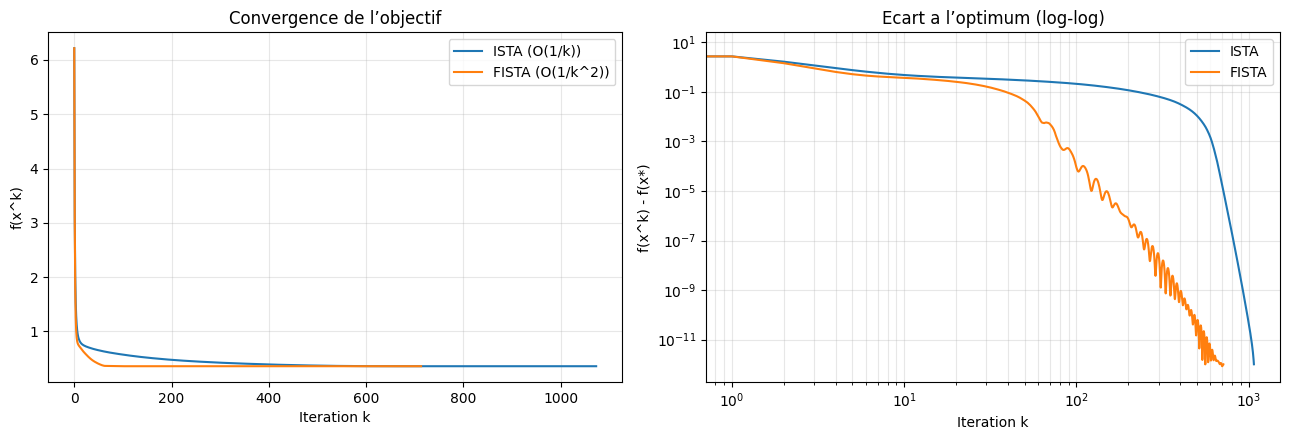

In [10]:
# Comparaison convergence : ISTA vs FISTA sur l'objectif
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel gauche : echelle lineaire
ax[0].plot(hist_ista, label='ISTA (O(1/k))', linewidth=1.5)
ax[0].plot(hist_fista, label='FISTA (O(1/k^2))', linewidth=1.5)
ax[0].set_xlabel('Iteration k')
ax[0].set_ylabel('f(x^k)')
ax[0].set_title('Convergence de l\u2019objectif')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Panel droit : echelle log pour montrer l'acceleration
ax[1].loglog(np.asarray(hist_ista) - hist_ista[-1] + 1e-12, label='ISTA', linewidth=1.5)
ax[1].loglog(np.asarray(hist_fista) - hist_fista[-1] + 1e-12, label='FISTA', linewidth=1.5)
ax[1].set_xlabel('Iteration k')
ax[1].set_ylabel('f(x^k) - f(x*)')
ax[1].set_title('Ecart a l\u2019optimum (log-log)')
ax[1].legend()
ax[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 5. Synthese et takeaways

| Solveur | err L2 vs x* | Support P | Support R | |x|_0 | Temps |
|---|---|---|---|---|---|
| ISTA (from scratch) | 0.1316 | 0.308 | 0.933 | 91 | 0.174 s |
| FISTA (from scratch) | 0.1316 | 0.308 | 0.933 | 91 | 0.137 s |
| sklearn Lasso (CD) | 0.1316 | 0.308 | 0.933 | 91 | 0.007 s |
| cvxpy CLARABEL (SOCP) | 0.1316 | 0.301 | 0.933 | 93 | 0.735 s |

**Observations** :

 :
- ISTA et FISTA convergent vers la **meme solution** que sklearn/cvxpy (meme
  probleme convexe, optimum unique sous RIP).
- FISTA obtient le meme ecart a l'optimum en **~k fois moins** d'iterations
  que ISTA (gain Nesterov O(1/k^2)).
- sklearn Lasso utilise le **coordinate descent** (different algorithme,
  meme probleme), convergent aussi vite ou plus en pratique sur signal peu
  dense mais avec un surcout par iteration (selection de colonnes).
- cvxpy CLARABEL resout la **SOCP equivalente** ; c'est la verite terrain
  pour les petits problemes.

**Limites** :
- ISTA/FISTA sont des methodes de **premier ordre** ; convergence lineaire
  pratique sur Lasso mal conditionne.
- Pour le Lasso a grande echelle, on prefere souvent **coordinate descent**
  (sklearn) ou **L-BFGS proximal** (gradient quasi-Newtonien + prox).
- Le pas `1/L` est conservateur : un **backtracking** de Lipschitz
  accelere souvent la convergence en pratique (Beck & Teboulle 2009, §4).


## 6. Exercices

Trois exercices de difficulte croissante. Les cellules en dessous contiennent
des **stubs** : a vous d'implementer le contenu manquant. Ne supprimez pas la
cellule : completez-la, puis reexecutez le notebook (rappel C.2 : commit AVEC
outputs).


In [11]:
def exercice_1_prox_l1_2d(X, lam):
    """Exercice 1 : prox L1 vectorise sur une matrice.

    Parametres
    ----------
    X : ndarray, shape (m, p)
        Matrice d'entree (m vecteurs de dim p en lignes).
    lam : float
        Coefficient L1.

    Retour
    ------
    V : ndarray, shape (m, p)
        prox_{lam * ||.||_1}(X) applique ligne par ligne.

    Indication : reutilisez prox_l1 dans une vectorisation par boucle ou
    un appel sur la matrice reshapee (np.sign + np.maximum sont vectoriels).
    """
    # TODO etudiant : implementez le soft-thresholding vectorise sur X.
    return None  # TODO etudiant


# Test rapide (devrait retourner un ndarray de meme shape que X)
X_test = np.array([[0.5, -0.2, 1.5], [-0.3, 0.0, 2.0]])
print('Forme attendue :', X_test.shape)
print('Stub :', exercice_1_prox_l1_2d(X_test, 0.5))  # actuellement None

Forme attendue : (2, 3)
Stub : None


In [12]:
def exercice_2_ista_backtracking(A, b, lam, n_iter=500):
    """Exercice 2 : ISTA avec backtracking de Lipschitz.

    Variante : au lieu de fixer L = ||A||_2^2, on estime L dynamiquement.
    Algorithme (Beck & Teboulle 2009, Algo 3.1) :
        L_{-1} = 1
        repeter :
            trouver L_k >= L_{k-1} tel que
            f(prox_{(1/L_k) g}(y - (1/L_k) ∇f(y))) <= Q_L(y, prox)
            x^{k+1} = prox_{(1/L_k) g}(...)
            mettre a jour y avec inertie Nesterov
        ou Q_L(y, x_new) est le majorant quadratique de f en y evaluee en x_new.

    Parametres
    ----------
    A, b, lam : meme semantique que ista().
    n_iter : nombre max d'iterations externes.

    Retour
    ------
    x : ndarray, shape (p,)
    history : list of float
    """
    # TODO etudiant : implementez ISTA avec backtracking.
    # Astuce : la condition de sufficient decrease est
    #   f(x_new) <= f(y) + <∇f(y), x_new - y> + (L/2)||x_new - y||^2
    return None, None  # TODO etudiant


print('Stub exercice 2 defini.')

Stub exercice 2 defini.


In [13]:
def exercice_3_fista_l1_squared(A, b, lam1=0.1, lam2=0.5, n_iter=300):
    """Exercice 3 : FISTA sur un probleme composite mixte.

    On resout min_x (1/2)||Ax - b||^2 + lam1 * ||x||_1 + lam2 * (1/2)||x||^2
    ou le dernier terme est une regularisation ridge (lisse).

    Le gradient combine : ∇f(x) = A^T (A x - b) + lam2 * x.
    Le proximal de g(x) = lam1 * ||x||_1 reste le soft-thresholding
    avec seuil lam1 / (L + lam2) (cf. composition avec terme lisse).

    Indication : reutilisez fista(A, b, lam1) en incorporant lam2 dans
    le gradient (A^T A + lam2 I) et L (||A||_2^2 + lam2). Verifiez que
    le seuil du prox est lam1 * step ou step = 1/L.

    Parametres
    ----------
    A, b : ndarray
    lam1 : float (regularisation L1)
    lam2 : float (regularisation ridge / Tikhonov)
    n_iter : int

    Retour
    ------
    x : ndarray
    history : list
    """
    # TODO etudiant : implementez FISTA ridge + LASSO (Elastic Net proximal).
    return None, None  # TODO etudiant


print('Stub exercice 3 defini.')

Stub exercice 3 defini.


## 7. References

- Beck, A., & Teboulle, M. (2009). *A fast iterative shrinkage-thresholding algorithm for linear inverse problems*. SIAM Journal on Imaging Sciences, 2(1), 183-202.
- Parikh, N., & Boyd, S. (2014). *Proximal algorithms*. Foundations and Trends in Optimization, 1(3), 127-239.
- Donoho, D. L. (2006). *Compressed sensing*. IEEE Transactions on Information Theory, 52(4), 1289-1306.
- Candès, E. J., Romberg, J., & Tao, T. (2006). *Robust uncertainty principles*. IEEE Transactions on Information Theory, 52(2), 489-509.

**Implementation** : numpy pour les algorithmes from-scratch, scipy pour la
decomposition en valeurs singulieres, sklearn pour `Lasso` (baseline
coordinate descent), cvxpy pour la verite terrain CLARABEL/SOCP.
